In [3]:
import os, cv2, glob, random, shutil
import xml.etree.ElementTree as ET
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from tqdm.notebook import tqdm

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [4]:
class_map = {
    "WBC": 0,
    "RBC": 1,
    "Platelets": 2
}

In [ ]:
def convert_xml_to_yolo(xml_file, output_file):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        size = root.find('size')
        if size is None:
            return

        w = int(size.find('width').text)
        h = int(size.find('height').text)

        lines = []

        for obj in root.iter('object'):
            cls = obj.find('name').text

            if cls not in class_map:
                continue

            xmlbox = obj.find('bndbox')
            if xmlbox is None:
                continue

            xmin = int(xmlbox.find('xmin').text)
            xmax = int(xmlbox.find('xmax').text)
            ymin = int(xmlbox.find('ymin').text)
            ymax = int(xmlbox.find('ymax').text)

            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(w, xmax)
            ymax = min(h, ymax)

            bw = xmax - xmin
            bh = ymax - ymin

            if bw <= 0 or bh <= 0:
                continue

            x_center = ((xmin + xmax) / 2) / w
            y_center = ((ymin + ymax) / 2) / h
            width = bw / w
            height = bh / h

            cls_id = class_map[cls]
            lines.append(f"{cls_id} {x_center} {y_center} {width} {height}")

        if len(lines) > 0:
            os.makedirs(os.path.dirname(output_file), exist_ok=True)
            with open(output_file, "w") as f:
                f.write("\n".join(lines))

    except Exception as e:
        print(f"Error in {xml_file}: {e}")

In [6]:
xml_files = sorted(glob.glob(
    "dataset/Complete-Blood-Cell-Count-Dataset/*/Annotations/*.xml",
    recursive=True
))

for xml in xml_files:
    txt_path = xml.replace("Annotations", "labels").replace(".xml", ".txt")
    convert_xml_to_yolo(xml, txt_path)

Cek Overlap

In [7]:
import os

train_imgs = sorted(glob.glob("dataset/Complete-Blood-Cell-Count-Dataset/**/Training/**/*.jpg", recursive=True))
val_imgs   = sorted(glob.glob("dataset/Complete-Blood-Cell-Count-Dataset/**/Validation/**/*.jpg", recursive=True))

# ambil filename saja
train_names = set(os.path.basename(p) for p in train_imgs)
val_names   = set(os.path.basename(p) for p in val_imgs)

# cek overlap
overlap = train_names.intersection(val_names)

print(f"Total val images: {len(val_names)}")
print(f"Overlap with train: {len(overlap)}")
print("Sample overlap:", list(overlap)[:10])

Total val images: 60
Overlap with train: 60
Sample overlap: ['BloodImage_00217.jpg', 'BloodImage_00064.jpg', 'BloodImage_00137.jpg', 'BloodImage_00224.jpg', 'BloodImage_00212.jpg', 'BloodImage_00229.jpg', 'BloodImage_00019.jpg', 'BloodImage_00281.jpg', 'BloodImage_00166.jpg', 'BloodImage_00103.jpg']


Tahunya overlap berarti Validation set hanya randomized subset dari Training (BAD) -- Data Leakage

In [9]:
import os

train_imgs = sorted(glob.glob("dataset/Complete-Blood-Cell-Count-Dataset/**/Training/**/*.jpg", recursive=True))
val_imgs   = sorted(glob.glob("dataset/Complete-Blood-Cell-Count-Dataset/**/Testing/**/*.jpg", recursive=True))

# ambil filename saja
train_names = set(os.path.basename(p) for p in train_imgs)
test_names   = set(os.path.basename(p) for p in val_imgs)

# cek overlap
overlap = train_names.intersection(test_names)

print(f"Total Testing images: {len(test_names)}")
print(f"Overlap with train: {len(overlap)}")
print("Sample overlap:", list(overlap)[:10])

Total Testing images: 60
Overlap with train: 0
Sample overlap: []


Jadi pake Training sama Testing saja

In [10]:
train_imgs = sorted(glob.glob("dataset/Complete-Blood-Cell-Count-Dataset/**/Training/**/*.jpg", recursive=True))
test_imgs  = sorted(glob.glob("dataset/Complete-Blood-Cell-Count-Dataset/**/Testing/**/*.jpg", recursive=True))

all_imgs = train_imgs + test_imgs

print("Train original:", len(train_imgs))
print("Test original:", len(test_imgs))
print("Total used:", len(all_imgs))

Train original: 300
Test original: 60
Total used: 360


In [11]:
image_paths = all_imgs

valid_data = []

for img in image_paths:
    label = img.replace("Images", "labels").replace(".jpg", ".txt")

    if os.path.exists(label) and os.path.getsize(label) > 0:
        valid_data.append((img, label))

print(f"Total valid samples: {len(valid_data)}")

Total valid samples: 360


In [12]:
import os
from collections import Counter

# ambil hanya nama file image
filenames = [os.path.basename(img) for img, _ in valid_data]

# hitung frekuensi
counter = Counter(filenames)

# cari yang duplicate
duplicates = [name for name, count in counter.items() if count > 1]

print(f"Total duplicate filenames: {len(duplicates)}")
print("Sample duplicates:", duplicates[:10])

Total duplicate filenames: 0
Sample duplicates: []


In [13]:
train_data, temp_data = train_test_split(
    valid_data,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

val_data, test_data = train_test_split(
    temp_data,
    test_size=1/3,
    random_state=42,
    shuffle=True
)

print(f"Train: {len(train_data)}")
print(f"Val: {len(val_data)}")
print(f"Test: {len(test_data)}")

Train: 252
Val: 72
Test: 36


In [18]:
base_dir = "dataset/yolo_dataset"

for split in ["train", "val", "test"]:
    os.makedirs(f"{base_dir}/images/{split}", exist_ok=True)
    os.makedirs(f"{base_dir}/labels/{split}", exist_ok=True)

In [19]:
def copy_data(data, split):
    for img, label in data:
        shutil.copy(img, f"{base_dir}/images/{split}/{os.path.basename(img)}")
        shutil.copy(label, f"{base_dir}/labels/{split}/{os.path.basename(label)}")

copy_data(train_data, "train")
copy_data(val_data, "val")
copy_data(test_data, "test")

Train: Counter({1: 2874, 0: 262, 2: 232})
Val: Counter({1: 845, 2: 91, 0: 71})
Test: Counter({1: 414, 2: 36, 0: 35})


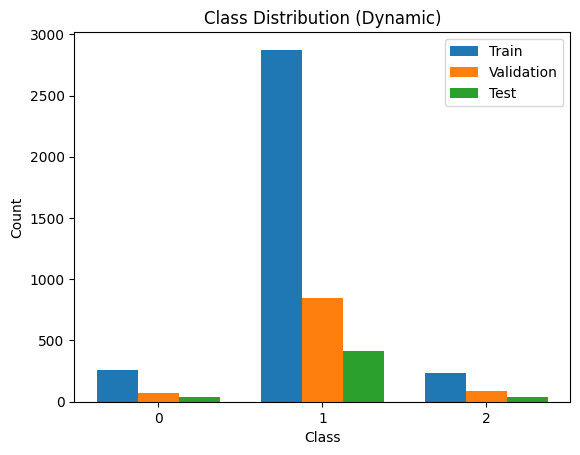

In [20]:
def count_classes(data):
    counter = Counter()

    for _, label in data:
        with open(label, "r") as f:
            for line in f:
                cls = int(line.split()[0])
                counter[cls] += 1

    return counter

print("Train:", count_classes(train_data))
print("Val:", count_classes(val_data))
print("Test:", count_classes(test_data))

train_counter = count_classes(train_data)
val_counter   = count_classes(val_data)
test_counter  = count_classes(test_data)

all_classes = sorted(set(train_counter) | set(val_counter) | set(test_counter))

train_values = [train_counter.get(c, 0) for c in all_classes]
val_values   = [val_counter.get(c, 0) for c in all_classes]
test_values  = [test_counter.get(c, 0) for c in all_classes]

x = range(len(all_classes))
width = 0.25

plt.figure()

plt.bar([i - width for i in x], train_values, width=width, label='Train')
plt.bar(x, val_values, width=width, label='Validation')
plt.bar([i + width for i in x], test_values, width=width, label='Test')

plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution (Dynamic)')
plt.xticks(x, all_classes)
plt.legend()

plt.show()

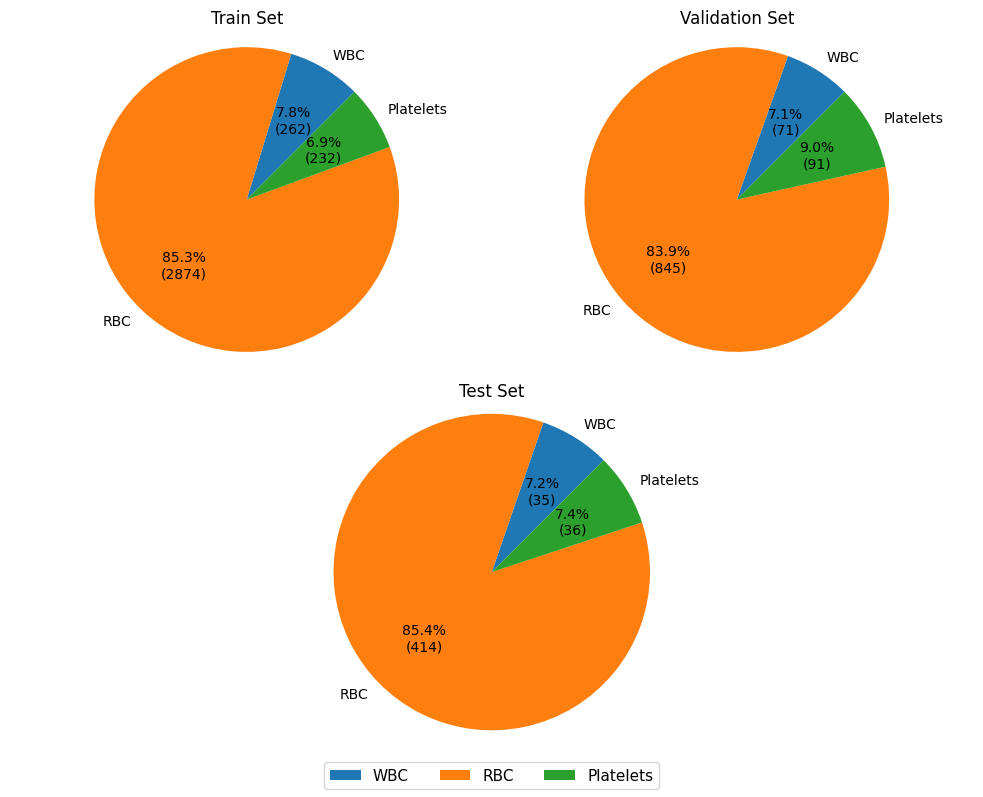

In [21]:
# Define class mapping
CLASS_NAMES = {
    0: "WBC",
    1: "RBC",
    2: "Platelets"
}

# Fixed class order
ALL_CLASSES = [0, 1, 2]

# Consistent colors (colorblind-friendly)
CLASS_COLORS = {
    0: "#1f77b4",  # blue
    1: "#ff7f0e",  # orange
    2: "#2ca02c",  # green
}

def count_classes(data):
    counter = Counter()

    for _, label in data:
        with open(label, "r") as f:
            for line in f:
                cls = int(line.split()[0])
                counter[cls] += 1

    return counter

def make_autopct(counter):
    total = sum(counter.values())

    def autopct(pct):
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count})"

    return autopct

def plot_pie(ax, counter, title):
    # Ensure consistent class order
    labels = [CLASS_NAMES[c] for c in ALL_CLASSES]
    sizes = [counter.get(c, 0) for c in ALL_CLASSES]
    colors = [CLASS_COLORS[c] for c in ALL_CLASSES]

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct=make_autopct(counter),
        startangle=45,
        textprops={'fontsize': 10}
    )

    ax.set_title(title, fontsize=12)
    ax.axis('equal')

    return wedges  # return for legend

# Count objects
train_counter = count_classes(train_data)
val_counter   = count_classes(val_data)
test_counter  = count_classes(test_data)

# Create figure layout
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])  # full width bottom

# Plot pies
wedges = plot_pie(ax1, train_counter, "Train Set")
plot_pie(ax2, val_counter, "Validation Set")
plot_pie(ax3, test_counter, "Test Set")

# Global legend (cleaner for report)
fig.legend(
    wedges,
    [CLASS_NAMES[c] for c in ALL_CLASSES],
    loc="lower center",
    ncol=3,
    fontsize=11
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()